In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline

### Dataset 

In [2]:
raw_df = pd.read_csv("/workspaces/ZoomML_Homeworks/homework_2/car_fuel_efficiency_2026.csv")
len(raw_df)

10000

In [3]:
df = raw_df.copy()[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0
...,...,...,...,...,...
9995,2470,271.0,4690,2005,27.4
9996,2300,244.0,4370,1993,30.0
9997,2480,267.0,4590,2014,28.1
9998,2180,270.0,4450,2004,32.2


### Exploratory Data Analysis (EDA)

Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 

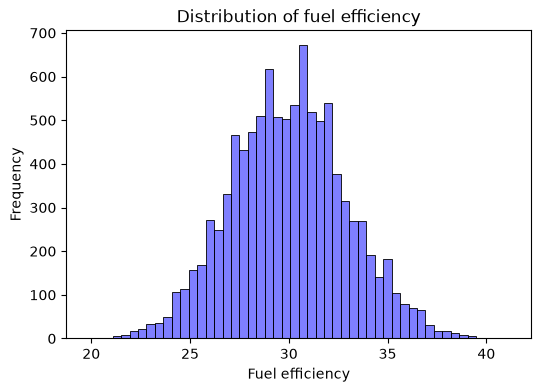

In [4]:
plt.figure(figsize=(6, 4))

sns.histplot(df.fuel_efficiency_mpg, bins=50, color='blue', alpha=0.5)
plt.ylabel('Frequency')
plt.xlabel('Fuel efficiency')
plt.title('Distribution of fuel efficiency')

plt.show()

In [5]:
print("This is not a long-tail distribution.")

This is not a long-tail distribution.


### Question 1: missing values

There's one column with missing values. What is it?

In [6]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

In [7]:
print("The column with missing values is horsepower.")

The column with missing values is horsepower.


### Question 2: median for horsepower

What's the median (50% percentile) for variable `'horsepower'`?

In [8]:
horsepower = df["horsepower"]
med_horsepower = horsepower.median()
print("The median for variable horsepower is: ", med_horsepower)

The median for variable horsepower is:  254.0


### Prepare and split the dataset

In [9]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

### Question 3: filling NAs

We need to deal with missing values for the column from Question 1. 

There are two options: fill it with 0 or with the mean of this variable.

Try both options; for each, train a linear regression model without regularization.
- For computing the mean, use the training only.
- Use the validation dataset to evaluate the models and compare the RMSE of each option
- Round the RMSE scores to 3 decimal digits using `round(score, 3)`.

Which option gives better RMSE?

In [10]:
df_train.columns

Index(['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year',
       'fuel_efficiency_mpg'],
      dtype='str')

In [11]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']    

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

In [12]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])              #creiamo una colonna di 1 con indice 0
    X = np.column_stack([ones, X])          #aggiungiamo la colonna dei bias   

    XTX = X.T.dot(X)                        #Gram matrix 
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)             #Normal equation    
    
    return w[0], w[1:]

In [13]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

1. Fill the empty values with 0

In [15]:
X_train1 = df_train[base].fillna(0).values
X_train1

array([[1900.,  239., 3790., 2015.],
       [2000.,  224., 4380., 1992.],
       [2330.,  286., 4090., 2022.],
       ...,
       [2240.,  255., 4190., 1989.],
       [2430.,  254., 4280., 2020.],
       [2390.,  266., 4220., 1996.]], shape=(6000, 4))

In [16]:
w0_1, w_1 = train_linear_regression(X_train1, y_train)

In [17]:
X_val1 = df_val[base].fillna(0).values

In [18]:
y_pred1 = w0_1 + X_val1.dot(w_1)

In [19]:
rmse1 = rmse(y_val, y_pred1)
rmse1_arr = round(rmse1, 3)

<Axes: ylabel='Count'>

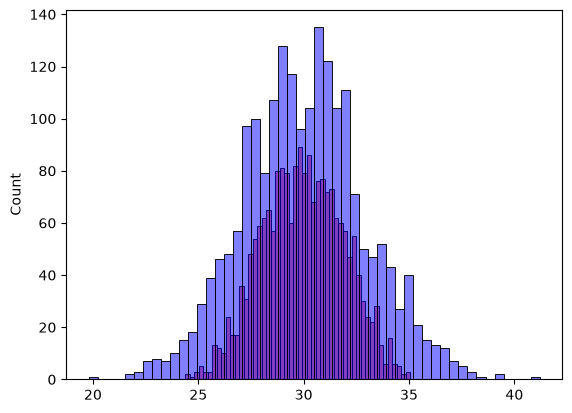

In [20]:
sns.histplot(y_pred1, color = 'red', alpha = 0.5, bins = 50)
sns.histplot(y_val, color = 'blue', alpha = 0.5, bins = 50)

In [21]:
print("RMSE (with zeros): ", rmse1_arr)

RMSE (with zeros):  2.205


2. Fill the empty values with the mean of horsepower values

In [22]:
horsepower_train = df_train["horsepower"]
mean_horsepower_train = horsepower_train.mean()
mean_horsepower_train

np.float64(254.46338337605272)

In [23]:
X_train2 = df_train[base].fillna(mean_horsepower_train).values

In [24]:
w0_2, w_2 = train_linear_regression(X_train2, y_train)

In [25]:
X_val2 = df_val[base].fillna(mean_horsepower_train).values

In [26]:
y_pred2 = w0_2 + X_val2.dot(w_2)

In [27]:
rmse2 = rmse(y_val, y_pred2)
rmse2_arr = round(rmse2, 3)

<Axes: ylabel='Count'>

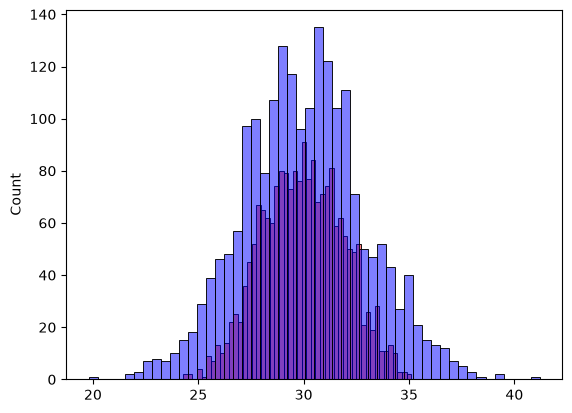

In [28]:
sns.histplot(y_pred2, color = 'red', alpha = 0.5, bins = 50)
sns.histplot(y_val, color = 'blue', alpha = 0.5, bins = 50)

In [29]:
print("RMSE (with mean value): ", rmse2_arr)

RMSE (with mean value):  2.202






### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.